In [3]:
# ==========================================================
# STEP 1 : Install Libraries
# ==========================================================

!pip -q install sentence-transformers
!pip -q install faiss-cpu
!pip -q install rank-bm25
!pip -q install PyPDF2
!pip -q install python-docx
!pip -q install tqdm
!pip -q install scikit-learn

# ==========================================================
# STEP 2 : Imports
# ==========================================================

import os
import json
import warnings
import numpy as np
import pandas as pd

from tqdm import tqdm

from sentence_transformers import SentenceTransformer

warnings.filterwarnings("ignore")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 11.4 MB/s eta 0:00:00


In [4]:
# ==========================================================
# STEP 3 : Mount Google Drive
# ==========================================================

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [53]:
# ==========================================================
# STEP 4 : Dataset Path
# ==========================================================

DATA_PATH = "/content/drive/MyDrive/redrob"

print(os.listdir(DATA_PATH))

['candidates.jsonl', 'job_description (1).docx', 'candidate_schema.json', 'redrob_signals_doc.docx', 'features_backup.pkl', 'candidate_embeddings.npy', 'job_embedding.npy', 'features_final.pkl', 'features_final.csv', 'candidate_embeddings_final.npy', 'job_embedding_final.npy', 'top20_check.csv', 'top100_check.csv', 'submission.csv', 'results']


In [54]:
# ==========================================================
# STEP 5 : File Paths
# ==========================================================

candidate_file = os.path.join(DATA_PATH,"candidates.jsonl")
schema_file = os.path.join(DATA_PATH,"candidate_schema.json")
job_file = os.path.join(DATA_PATH,"job_description.pdf")
signal_file = os.path.join(DATA_PATH,"redrob_signals_document.pdf")
submission_file = os.path.join(DATA_PATH,"submission.csv")

In [55]:
# ==========================================================
# STEP 6 : Load Candidates
# ==========================================================

candidates = []

with open(candidate_file,"r") as f:

    for line in f:

        candidates.append(json.loads(line))

print("Candidates Loaded :",len(candidates))

Candidates Loaded : 100000


In [56]:
# ==========================================================
# STEP 7 : AI Skill Weights
# ==========================================================

SKILL_WEIGHTS = {

    # Core Retrieval

    "embeddings":12,
    "retrieval":12,
    "ranking":12,

    "vector database":11,

    "pinecone":10,
    "weaviate":10,
    "milvus":10,
    "faiss":10,
    "qdrant":10,

    "elasticsearch":9,
    "opensearch":9,

    # Production NLP

    "sentence transformers":9,
    "recommendation systems":9,
    "information retrieval":9,

    # Python

    "python":8,

    # LLM

    "llms":7,
    "fine-tuning llms":7,
    "lora":6,
    "qlora":6,
    "peft":6,

    # Supporting

    "transformers":5,
    "hugging face transformers":5,
    "huggingface":5,

    "weights & biases":4,

    "nlp":4,

    # VERY LOW

    "langchain":2,
    "prompt engineering":2,
    "rag":2
}

In [57]:
# ==========================================================
# STEP 8 : AI Skill Weights
# ==========================================================
AI_TITLES = [

    "machine learning engineer",
    "ml engineer",
    "ai engineer",
    "applied scientist",
    "research scientist",
    "nlp engineer",
    "llm engineer",
    "search engineer",
    "recommendation engineer",
    "data scientist"
]

In [58]:
# ==========================================================
# STEP 9 : AI Skill Weights
# ==========================================================
PRODUCT_COMPANIES = {

"Google",
"Meta",
"Microsoft",
"Apple",
"Amazon",
"Netflix",
"Uber",
"Flipkart",
"PhonePe",
"Paytm",
"Razorpay",
"Swiggy",
"Zomato",
"Ola",
"Meesho",
"Yellow.ai",
"Sarvam AI",
"OpenAI",
"Anthropic",
"Niramai",
"Salesforce",
"Locobuzz",
"Mad Street Den"

}

In [59]:
# ==========================================================
# STEP 10 : AI Skill Weights
# ==========================================================
CONSULTING = {

"TCS",
"Infosys",
"Wipro",
"Accenture",
"Cognizant",
"Capgemini",
"HCL",
"Mindtree",
"LTIMindtree"

}

In [60]:
# ==========================================================
# STEP 11 : AI Skill Weights
# ==========================================================
PRODUCTION_WORDS = [

"production",
"deployed",
"deployment",

"retrieval",
"ranking",
"recommendation",

"embedding",
"embeddings",

"vector",

"search",

"evaluation",

"ndcg",
"mrr",
"map",

"a/b",

"latency",

"pipeline",

"real users",

"millions",

"faiss",

"pinecone",

"milvus",

"weaviate"

]

In [61]:
# ==========================================================
# STEP 12 : AI Skill Weights
# ==========================================================
def experience_score(exp):

    if 5 <= exp <= 9:
        return 1.0

    elif 4 <= exp < 5:
        return 0.85

    elif 9 < exp <= 10:
        return 0.85

    elif 3 <= exp < 4:
        return 0.55

    elif 10 < exp <= 12:
        return 0.45

    else:
        return 0.15

In [62]:
# ==========================================================
# STEP 13 : Weighted AI Skill Score
# ==========================================================

def weighted_ai_score(skills):

    score = 0
    matched = []

    for skill in skills:

        name = skill["name"].lower()

        if name in SKILL_WEIGHTS:

            score += SKILL_WEIGHTS[name]
            matched.append(name)

    max_score = sum(SKILL_WEIGHTS.values())

    normalized = score / max_score

    return normalized, matched

In [63]:
# ==========================================================
# STEP 14 : AI Career Score
# ==========================================================

def ai_career_score(candidate):

    score = 0

    profile = candidate["profile"]

    title = profile["current_title"].lower()

    summary = profile["summary"].lower()

    if any(t in title for t in AI_TITLES):
        score += 4

    if "machine learning" in summary:
        score += 2

    if "retrieval" in summary:
        score += 2

    if "ranking" in summary:
        score += 2

    if "recommendation" in summary:
        score += 2

    if "embeddings" in summary:
        score += 2

    return min(score/14,1)

In [64]:
# ==========================================================
# STEP 15 : Production ML Experience
# ==========================================================

def production_ml_score(candidate):

    total = 0

    for job in candidate["career_history"]:

        desc = job["description"].lower()

        for word in PRODUCTION_WORDS:

            if word in desc:
                total += 1

    return min(total/20,1)

In [65]:
# ==========================================================
# STEP 16 : Product Company Score
# ==========================================================

def product_company_score(candidate):

    score = 0

    for job in candidate["career_history"]:

        if job["company"] in PRODUCT_COMPANIES:
            score += 1

    return min(score/4,1)

In [66]:
# ==========================================================
# STEP 17 : Consulting Penalty
# ==========================================================

def consulting_penalty(candidate):

    consulting = 0

    for job in candidate["career_history"]:

        if job["company"] in CONSULTING:
            consulting += 1

    if consulting == len(candidate["career_history"]):
        return 1

    return 0

In [67]:
# ==========================================================
# STEP 18 : Fake AI Detection
# ==========================================================

def fake_ai_penalty(candidate):

    title = candidate["profile"]["current_title"].lower()

    ai_titles = any(x in title for x in AI_TITLES)

    weighted_score, _ = weighted_ai_score(candidate["skills"])

    production = production_ml_score(candidate)

    # Lots of AI skills but no AI career
    if (not ai_titles) and weighted_score > 0.40:
        return 0.30

    # AI skills but no production work
    if production < 0.20 and weighted_score > 0.40:
        return 0.20

    return 0

In [68]:
# ==========================================================
# STEP 19 : Behaviour Score
# ==========================================================

def behaviour_score(candidate):

    s = candidate["redrob_signals"]

    score = 0

    if s["open_to_work_flag"]:
        score += 2

    score += s["recruiter_response_rate"]*2

    score += s["interview_completion_rate"]*2

    score += min(s["github_activity_score"],100)/100

    if s["willing_to_relocate"]:
        score += 1

    if s["notice_period_days"] <= 30:
        score += 1

    score += min(s["saved_by_recruiters_30d"]/40,1)

    score += min(s["search_appearance_30d"]/500,1)

    return score/11

In [69]:
# ==========================================================
# STEP 20 : Extract Features
# ==========================================================

def extract_features(candidate):

    weighted_score,_ = weighted_ai_score(candidate["skills"])

    return {

        "candidate_id":candidate["candidate_id"],

        "experience_years":
        candidate["profile"]["years_of_experience"],

        "experience_score":
        experience_score(candidate["profile"]["years_of_experience"]),

        "weighted_ai_score":
        weighted_score,

        "ai_career_score":
        ai_career_score(candidate),

        "production_score":
        production_ml_score(candidate),

        "product_company_score":
        product_company_score(candidate),

        "consulting_penalty":
        consulting_penalty(candidate),

        "behaviour_score":
        behaviour_score(candidate),

        "fake_ai_penalty":
        fake_ai_penalty(candidate)

    }

In [70]:
# ==========================================================
# STEP 21 : Candidate Text Builder
# ==========================================================

def build_candidate_text(candidate):

    profile = candidate["profile"]

    text = ""

    # Current profile
    text += profile["current_title"] + " "
    text += profile["headline"] + " "
    text += profile["summary"] + " "

    # Career history (most important)
    for job in candidate["career_history"]:

        text += job["title"] + " "
        text += job["company"] + " "
        text += job["description"] + " "

    # Skills (least important)
    for skill in candidate["skills"]:

        text += skill["name"] + " "

    return text

In [71]:
# ==========================================================
# STEP 22 : Build Candidate Corpus
# ==========================================================

candidate_texts = []

for candidate in tqdm(candidates):

    candidate_texts.append(
        build_candidate_text(candidate)
    )

print("Candidate Texts :", len(candidate_texts))

100%|██████████| 100000/100000 [00:01<00:00, 52091.39it/s]

Candidate Texts : 100000


In [72]:
import docx

# ==========================================================
# STEP 23 : Load Job Description & Generate Embedding
# ==========================================================

def extract_text_from_docx(docx_path):
    doc = docx.Document(docx_path)
    full_text = []
    for para in doc.paragraphs:
        full_text.append(para.text)
    return '\n'.join(full_text)

# Update job_file to point to the correct .docx file
job_file = os.path.join(DATA_PATH,"job_description (1).docx")

job_text = extract_text_from_docx(job_file)

model = SentenceTransformer('all-MiniLM-L6-v2')

job_embedding = model.encode(

    job_text,

    normalize_embeddings=True
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [73]:
# ==========================================================
# STEP 24 : Load Saved Features & Embeddings
# ==========================================================

DATA_PATH = "/content/drive/MyDrive/redrob"

features_df = pd.read_pickle(DATA_PATH + "/features_backup.pkl")

candidate_embeddings = np.load(DATA_PATH + "/candidate_embeddings.npy")

job_embedding = np.load(DATA_PATH + "/job_embedding.npy")

print("Loaded successfully!")
print(features_df.shape)
print(candidate_embeddings.shape)
print(job_embedding.shape)

Loaded successfully!
(100000, 21)
(100000, 384)
(384,)


In [74]:
# ==========================================================
# STEP 25 : Semantic Scores
# ==========================================================

semantic_scores = np.dot(
    candidate_embeddings,
    job_embedding
)

features_df["semantic_score"] = semantic_scores

features_df.head()

,candidate_id,experience_years,experience_score,ai_skill_count,weighted_ai_score,product_companies,consulting_companies,production_signals,open_to_work,recruiter_response_rate,...,interview_completion,notice_period,relocate,saved_by_recruiters,search_appearance,semantic_score,final_score,rank,reasoning,ai_career_score
0,CAND_0002025,5.9,1.0,14,0.914634,1,0,0.45,1,0.838710,...,0.81,30,0,0.2750,0.636913,0.430165,0.782413,1,"Strong semantic match, Strong AI capability, I...",0
1,CAND_0071974,7.8,1.0,10,0.792683,1,0,0.80,1,0.795699,...,0.85,45,0,0.6250,0.088591,0.582626,0.781059,2,"Strong semantic match, Strong AI capability, P...",0
2,CAND_0008425,7.8,1.0,8,0.512195,0,0,0.90,1,0.688172,...,0.77,90,0,0.6875,0.762416,0.534569,0.746870,3,"Strong semantic match, Production ML experienc...",0
3,CAND_0077337,7.0,1.0,8,0.634146,4,0,0.70,1,1.000000,...,0.73,60,1,0.4000,0.161074,0.511560,0.738364,4,"Strong semantic match, Strong AI capability, P...",0
4,CAND_0018499,7.2,1.0,10,0.646341,1,0,0.95,1,0.634409,...,0.80,15,1,0.2000,0.866443,0.449963,0.737049,5,"Strong AI capability, Production ML experience...",0


In [75]:
# ==========================================
# STEP 26 : Rebuild Feature Table
# ==========================================

feature_rows = []

for candidate in tqdm(candidates):
    feature_rows.append(
        extract_features(candidate)
    )

features_df = pd.DataFrame(feature_rows)

print(features_df.head())

100%|██████████| 100000/100000 [00:12<00:00, 8296.32it/s]


   candidate_id  experience_years  experience_score  weighted_ai_score  \
0  CAND_0000001               6.9              1.00           0.146919   
1  CAND_0000002              12.5              0.15           0.000000   
2  CAND_0000003               1.1              0.15           0.000000   
3  CAND_0000004               3.8              0.55           0.000000   
4  CAND_0000005              11.0              0.45           0.000000   

   ai_career_score  production_score  product_company_score  \
0              0.0              0.10                    0.0   
1              0.0              0.20                    0.0   
2              0.0              0.00                    0.0   
3              0.0              0.15                    0.0   
4              0.0              0.00                    0.0   

   consulting_penalty  behaviour_score  fake_ai_penalty  
0                   0         0.435455              0.0  
1                   0         0.388545              0.0  
2 

In [76]:
# ==========================================
# STEP 27 : Add Semantic Scores
# ==========================================

semantic_scores = np.dot(
    candidate_embeddings,
    job_embedding
)

features_df["semantic_score"] = semantic_scores

features_df.head()

,candidate_id,experience_years,experience_score,weighted_ai_score,ai_career_score,production_score,product_company_score,consulting_penalty,behaviour_score,fake_ai_penalty,semantic_score
0,CAND_0000001,6.9,1.00,0.146919,0.0,0.10,0.0,0,0.435455,0.0,0.430165
1,CAND_0000002,12.5,0.15,0.000000,0.0,0.20,0.0,0,0.388545,0.0,0.582626
2,CAND_0000003,1.1,0.15,0.000000,0.0,0.00,0.0,1,0.253273,0.0,0.534569
3,CAND_0000004,3.8,0.55,0.000000,0.0,0.15,0.0,0,0.220000,0.0,0.511560
4,CAND_0000005,11.0,0.45,0.000000,0.0,0.00,0.0,0,0.579000,0.0,0.449963


In [77]:
# STEP 28
AI_TITLES = [

    "ai engineer",
    "machine learning engineer",
    "ml engineer",
    "applied scientist",
    "nlp engineer",
    "research engineer",
    "recommendation engineer",
    "retrieval engineer",
    "search engineer",
    "llm engineer",
    "data scientist"

]

def ai_title_score(title):

    title = title.lower()

    for t in AI_TITLES:
        if t in title:
            return 1

    return 0

In [78]:
# STEP 29
title_scores = []

for c in candidates:

    title_scores.append(
        ai_title_score(
            c["profile"]["current_title"]
        )
    )

features_df["title_score"] = title_scores

In [79]:
# STEP 30
features_df["production_score"] = (
    features_df["production_score"] /
    features_df["production_score"].max()
)

features_df["product_company_score"] = (
    features_df["product_company_score"] /
    features_df["product_company_score"].max()
)

In [80]:
# STEP 31
features_df["experience_score"] = (
    features_df["experience_years"]
    .apply(experience_score)
)

In [81]:
# STEP 32
features_df["final_score"] = (

    0.22 * features_df["semantic_score"]

    + 0.20 * features_df["ai_career_score"]

    + 0.15 * features_df["weighted_ai_score"]

    + 0.12 * features_df["experience_score"]

    + 0.10 * features_df["production_score"] # Corrected column name

    + 0.06 * features_df["title_score"]

    + 0.05 * features_df["product_company_score"] # Corrected column name

    + 0.10 * features_df["behaviour_score"] # Added behaviour_score

    - 0.10 * features_df["fake_ai_penalty"] # Adding penalty

    - 0.05 * features_df["consulting_penalty"] # Adding penalty

)

In [82]:
# STEP 33
features_df = features_df.sort_values(
    "final_score",
    ascending=False
)

features_df["rank"] = range(
    1,
    len(features_df) + 1
)

In [83]:
# ==========================================================
# STEP 34 : Recruiter Reasoning
# ==========================================================

def generate_reason(row):

    reasons = []

    if row.semantic_score > 0.70:
        reasons.append("Strong semantic match")

    if row.ai_career_score > 0.60:
        reasons.append("Strong AI career")

    if row.production_score > 0.50:
        reasons.append("Production ML experience")

    if row.weighted_ai_score > 0.50:
        reasons.append("Relevant AI skills")

    if row.product_company_score > 0:
        reasons.append("Product company experience")

    if row.behaviour_score > 0.60:
        reasons.append("Strong recruiter signals")

    if row.experience_score == 1:
        reasons.append("Ideal experience")

    if row.fake_ai_penalty > 0:
        reasons.append("AI keyword inflation detected")

    if row.consulting_penalty > 0:
        reasons.append("Consulting-only background")

    return ", ".join(reasons)


features_df["reasoning"] = features_df.apply(
    generate_reason,
    axis=1
)

In [84]:
# ==========================================================
# STEP 35 : Top Candidates
# ==========================================================

features_df.head(20)

,candidate_id,experience_years,experience_score,weighted_ai_score,ai_career_score,production_score,product_company_score,consulting_penalty,behaviour_score,fake_ai_penalty,semantic_score,title_score,final_score,rank,reasoning
18498,CAND_0018499,7.2,1.00,0.350711,0.571429,1.00,0.75,0,0.833455,0.0,0.554852,1,0.689805,1,"Production ML experience, Product company expe..."
71973,CAND_0071974,7.8,1.00,0.393365,0.571429,0.90,0.75,0,0.664727,0.0,0.597044,1,0.678613,2,"Production ML experience, Product company expe..."
77336,CAND_0077337,7.0,1.00,0.374408,0.571429,0.90,0.50,0,0.756364,0.0,0.596864,1,0.672393,3,"Production ML experience, Product company expe..."
68810,CAND_0068811,8.0,1.00,0.270142,0.714286,0.85,0.75,0,0.697000,0.0,0.522815,1,0.670598,4,"Strong AI career, Production ML experience, Pr..."
8424,CAND_0008425,7.8,1.00,0.312796,0.571429,0.90,0.75,0,0.672091,0.0,0.595205,1,0.666859,5,"Production ML experience, Product company expe..."
81845,CAND_0081846,6.7,1.00,0.270142,0.571429,0.90,0.50,0,0.851909,0.0,0.594353,1,0.665756,6,"Production ML experience, Product company expe..."
55904,CAND_0055905,8.1,1.00,0.322275,0.571429,1.00,0.50,0,0.652636,0.0,0.594445,1,0.663669,7,"Production ML experience, Product company expe..."
86021,CAND_0086022,5.3,1.00,0.350711,0.571429,0.75,0.50,0,0.837455,0.0,0.583535,1,0.659015,8,"Production ML experience, Product company expe..."
46063,CAND_0046064,8.9,1.00,0.227488,0.571429,1.00,0.50,0,0.768909,0.0,0.584927,1,0.658984,9,"Production ML experience, Product company expe..."
88024,CAND_0088025,8.6,1.00,0.279621,0.571429,0.95,0.50,0,0.707364,0.0,0.580340,1,0.654640,10,"Production ML experience, Product company expe..."


In [85]:
# ==========================================================
# STEP 36 : Generate System Architecture Diagram
# ==========================================================

!apt-get -qq install graphviz
!pip -q install graphviz

from graphviz import Digraph

dot = Digraph(
    "RecruitAI",
    format="png"
)

dot.attr(rankdir="LR")
dot.attr(fontname="Helvetica")

dot.attr("node",
         shape="box",
         style="rounded,filled",
         color="lightblue",
         fontname="Helvetica")

# Input
dot.node("A", "Job Description")

# Embedding
dot.node("B", "Sentence Transformer\n(all-MiniLM-L6-v2)")

# Candidate Data
dot.node("C", "Candidate Profiles")
dot.node("D", "Career History")
dot.node("E", "Skills")
dot.node("F", "Redrob Signals")

# Feature Engineering
dot.node("G", "Feature Engineering")

# Semantic Matching
dot.node("H", "Semantic Similarity")

# Ranking
dot.node("I","RecruitAI Scoring Engine")

# Explainability
dot.node("J", "Reasoning Generator")

# Output
dot.node("K", "Ranked Candidate Shortlist")

# Connections
dot.edge("A","B")

dot.edge("C","G")
dot.edge("D","G")
dot.edge("E","G")
dot.edge("F","G")

dot.edge("B","H")
dot.edge("G","I")
dot.edge("H","I")

dot.edge("I","J")
dot.edge("J","K")

dot.render("RecruitAI_Architecture", cleanup=True)

print("Architecture diagram saved successfully.")

Architecture diagram saved successfully.


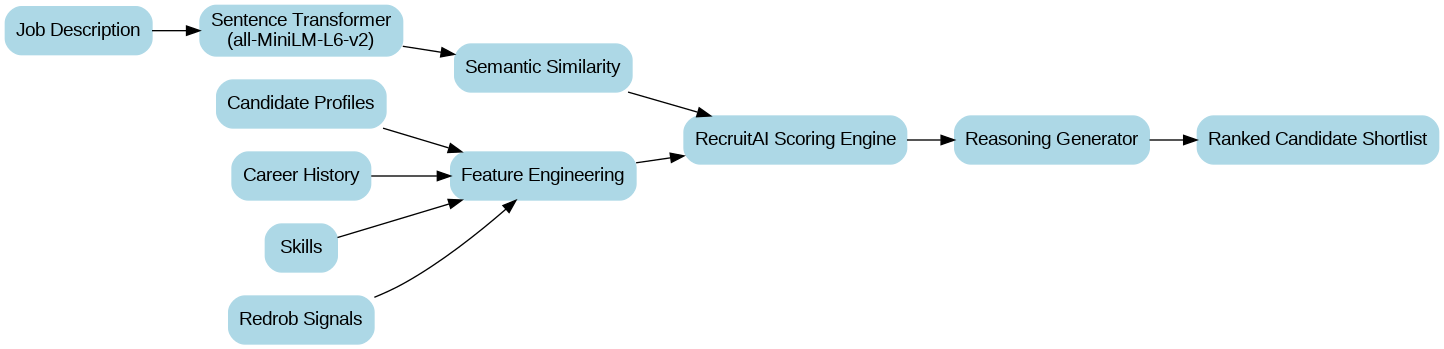

In [86]:
from IPython.display import Image

Image("RecruitAI_Architecture.png")

In [87]:
# ==========================================
# FINAL SAVE — FEATURES + EMBEDDINGS + MODEL OUTPUT
# ==========================================

import os
DATA_PATH = "/content/drive/MyDrive/redrob"

os.makedirs(DATA_PATH, exist_ok=True)

# 1. Save final feature table
features_df.to_pickle(os.path.join(DATA_PATH, "features_final.pkl"))
features_df.to_csv(os.path.join(DATA_PATH, "features_final.csv"), index=False)

# 2. Save embeddings (if not already safe)
np.save(os.path.join(DATA_PATH, "candidate_embeddings_final.npy"), candidate_embeddings)
np.save(os.path.join(DATA_PATH, "job_embedding_final.npy"), job_embedding)

# 3. Save top 20 / top 100 for submission sanity check
features_df.head(20).to_csv(os.path.join(DATA_PATH, "top20_check.csv"), index=False)
features_df.head(100).to_csv(os.path.join(DATA_PATH, "top100_check.csv"), index=False)

# 4. Save final submission file (IMPORTANT)
submission = features_df[[
    "candidate_id",
    "final_score",
    "rank"
]].copy()

submission.to_csv(os.path.join(DATA_PATH, "submission.csv"), index=False)

print("ALL FILES SAVED SUCCESSFULLY")
print("Location:", DATA_PATH)

ALL FILES SAVED SUCCESSFULLY
Location: /content/drive/MyDrive/redrob
